In [1]:
import sys
sys.path.append('..')
from experiment_utils import read_config_file, get_site_splits
from utils import get_project_dir
from eval_utils import compare_aligned_data

import numpy as np
import os
import rasterio

import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import pandas as pd
import seaborn as sns


In [2]:
# to get the different test sets
config_fp = '../experiment_configs/train_baseline_local_models.yaml'
cfg_hp_search = read_config_file(config_fp)
cfg_data = cfg_hp_search['data']
split_seed = cfg_data['split_seed']

resolution=10

In [3]:
project_dir = '..' #get_project_dir()
lidar_coarsened_dir = f'{project_dir}/data/int/lidar/lidar_by_site_32736_{resolution}m'
outputs_dir = '/n/tambe_lab/Everyone/model_output/subsetted_train_sites'

resolution= 10
reference_maps = ['ETH', 'GLAD', 'META', 'pauls']
#models = [f'local_only_models/128_filters/{x}' for x in ['3_channels', '4_channels', '12_channels', '15_channels']]
models = [f'local_only_models/128_filters/{x}' for x in ['12_channels']]

#pred padding is defined by how we cropped the satellite imagery to Karingani sites
pred_padding = 40

eval_metric = 'rmse'

sites = sorted([x for x in os.listdir(lidar_coarsened_dir) if not x.startswith('.')])

# Visualize predictions


In [4]:
model = 'local_only_models/128_filters/12_channels/12_train_sites/seed_0'
#model = 'finetune_xceptionS2/randominit_nolatlon/3_layers_tuned/12_train_sites/seed_0'

model_output_dir = f'{outputs_dir}/{model}'
existing_maps_dir = f'../../tree_mapping/data/existing_reference_data'

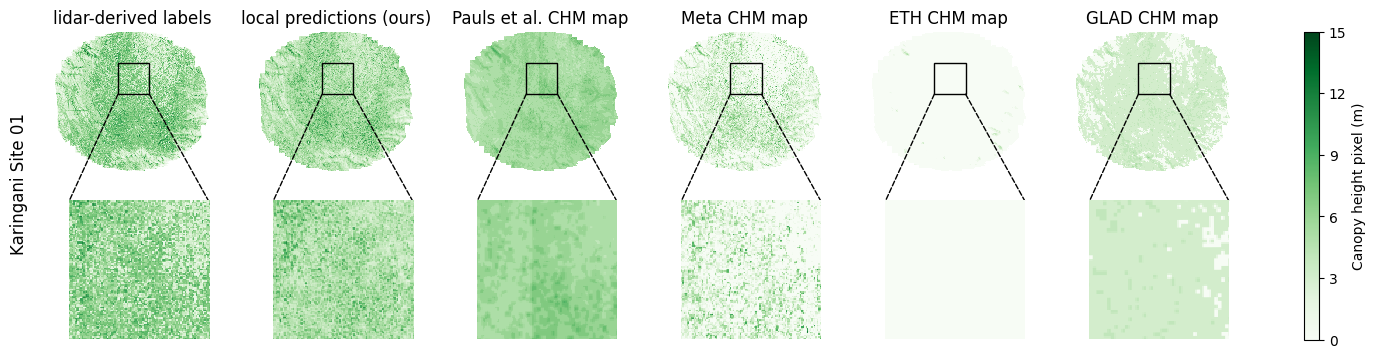

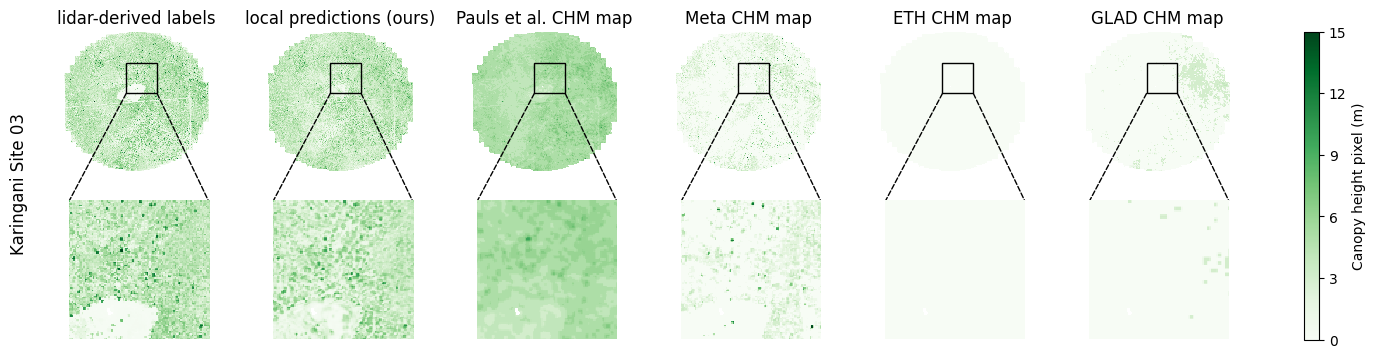

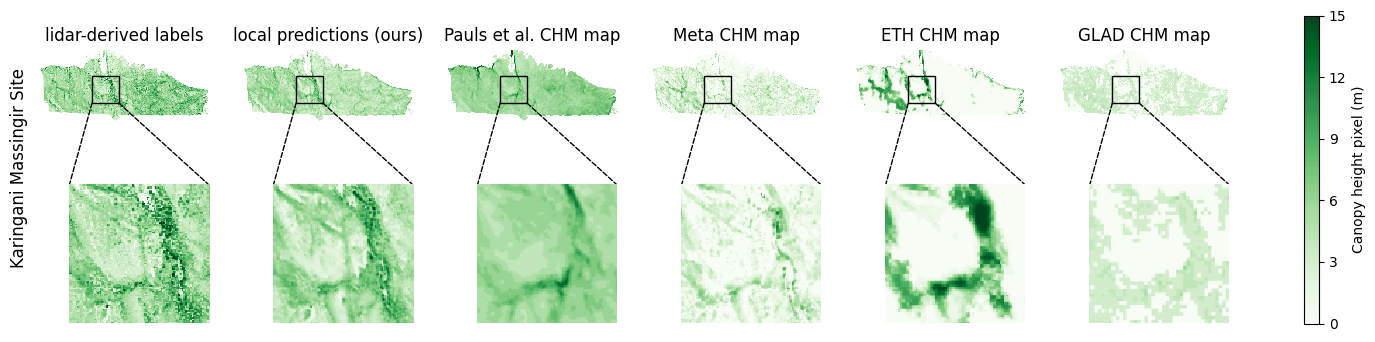

In [6]:
plot_sites = ['KaringaniSite01', 'KaringaniSite03', 'KaringaniMassingirDevNode']
plot_site_titles = ['Karingani Site 01', 'Karingani Site 03', 'Karingani Massingir Site']

x1, x2, y1,y2 = 200,300,100,200

for s,site in enumerate(plot_sites):
    with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
        site_labels = file.read()[0]

    with rasterio.open(f'{model_output_dir}/preds_{site}.tif') as file: # opens prediction tiff
        site_preds = file.read()[0,pred_padding:-pred_padding,pred_padding:-pred_padding]
        site_preds = site_preds#.clip(0,30) 
        
    with rasterio.open(f'{existing_maps_dir}/glad_maps_per_site_{resolution}m/GLAD_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        glad_preds = file.read()[0]
        
    with rasterio.open(f'{existing_maps_dir}/eth_maps_per_site_{resolution}m/ETH_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        eth_preds = file.read()[0]
        
    with rasterio.open(f'{existing_maps_dir}/meta_maps_per_site_{resolution}m/META_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        meta_preds = file.read()[0]
        
    with rasterio.open(f'/n/tambe_lab/Everyone/tree_mapping/existing_reference_data/pauls_maps_per_site_{resolution}m/PAULS_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        pauls_preds = file.read()[0]
        
    map_labels = [f'lidar-derived labels',
                  'local predictions (ours)',
                  'Pauls et al. CHM map',
                  'Meta CHM map',
                  'ETH CHM map',
                  'GLAD CHM map',
                 ]
                  
    maps_to_print = [x.copy() for x in [site_labels, site_preds, pauls_preds, meta_preds, eth_preds, glad_preds]]
    mask = site_labels < 0
    for x in maps_to_print:
        x[mask] = np.nan

    fig, ax = plt.subplots(2,len(maps_to_print),figsize=(len(maps_to_print)*3.2,4))
    for i, map_to_print in enumerate(maps_to_print):
        ax[0,i].imshow(map_to_print, vmin=0, vmax=15, 
                       cmap='Greens', 
                       interpolation='none')
        ax[0,i].set_title(map_labels[i])
        
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='black', facecolor='none')
        # Add the patch to the Axes
        ax[0,i].add_patch(rect)
    
        cbar_im = ax[1,i].imshow(map_to_print[y1:y2,x1:x2], vmin=0, vmax=15, 
                                 cmap='Greens', interpolation='none')
        
        line1 = patches.ConnectionPatch(
            xyA=(x1, y2), coordsA='data', axesA=ax[0,i],
            xyB=(0,0), coordsB='data', axesB=ax[1,i],
            color='black', lw=1, ls='--', zorder=-2
        )
        
        line2 = patches.ConnectionPatch(
            xyA=(x2, y2), coordsA='data', axesA=ax[0,i],
            xyB=(x2-x1-1,0), coordsB='data', axesB=ax[1,i],
            color='black', lw=1, ls='--', zorder=-2
        )
        ax[1,i].add_artist(line1)
        ax[1,i].add_artist(line2)
        line1.set_in_layout(False)
        line2.set_in_layout(False)

    

    for row in ax:
        for ax_this in row:
            ax_this.axis('off')
            
    # cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(cbar_im, ax=ax.ravel().tolist(), label=f'Canopy height pixel (m)', ticks = [0,3,6,9,12,15])
    
    fig.supylabel(plot_site_titles[s], x=.11)
    plt.savefig(f'../figures/qualitative_insets_{site}.png', bbox_inches='tight')

In [ ]:
os.listdir('/n/tambe_lab/Everyone/tree_mapping/existing_reference_data/pauls_maps_per_site_10m')

In [7]:
# plot separately

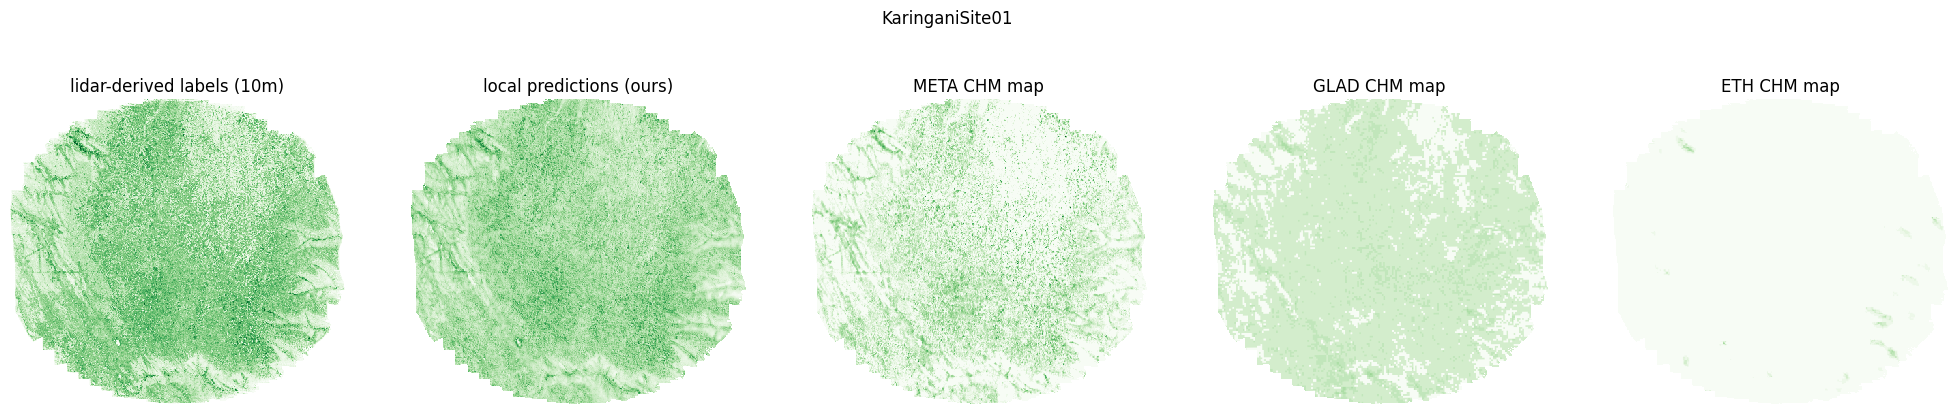

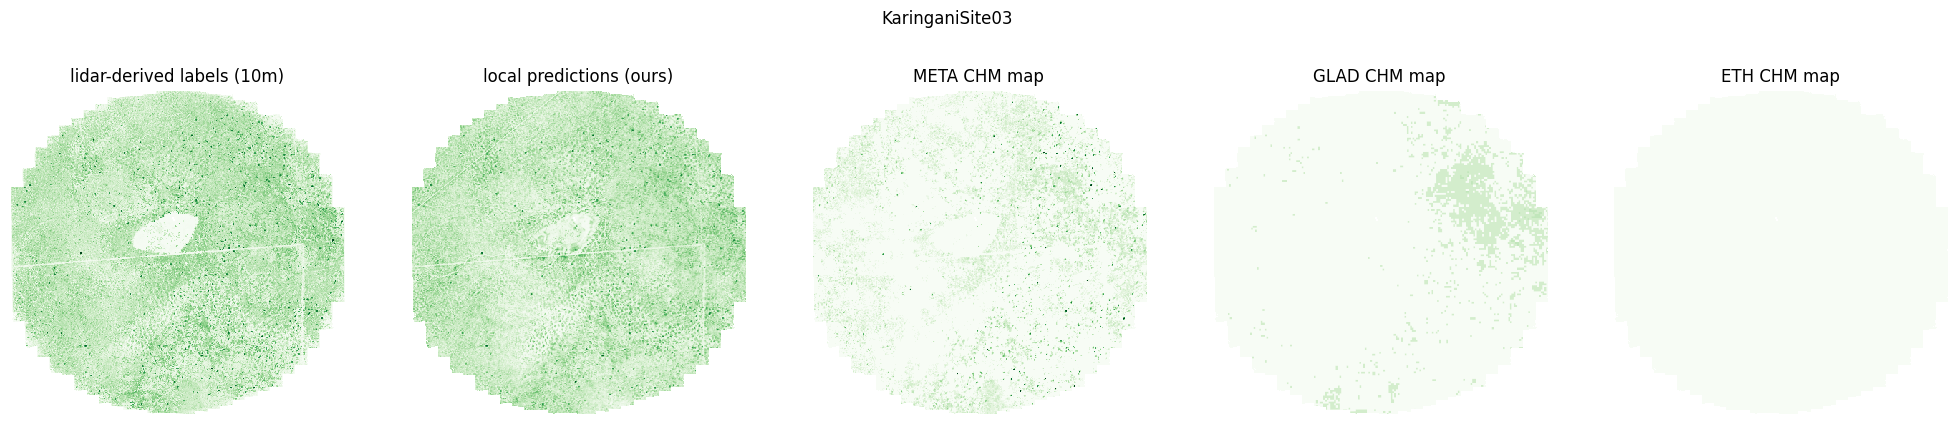

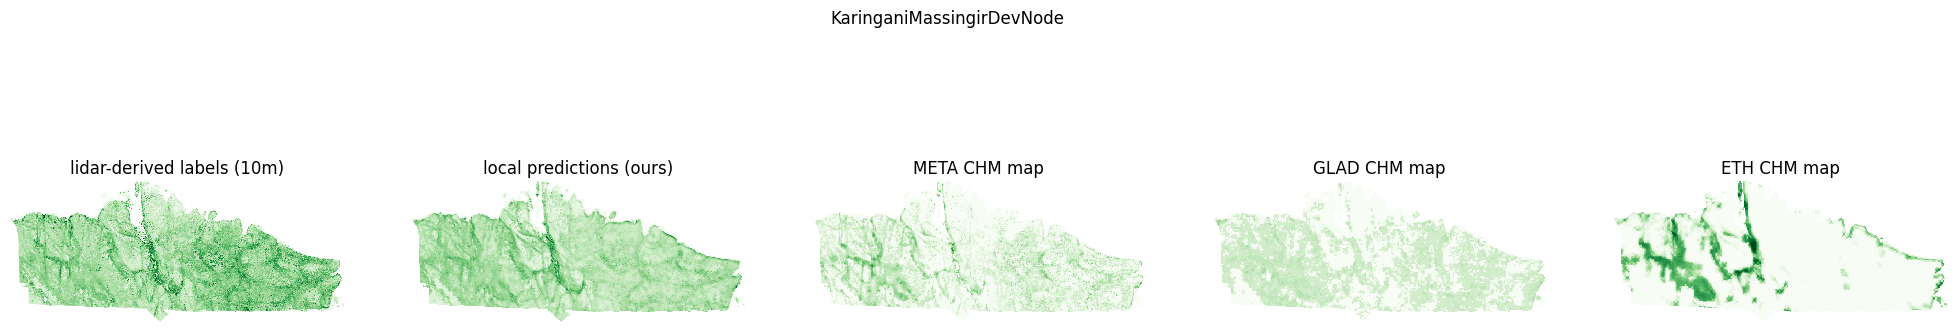

In [8]:
plot_sites = ['KaringaniSite01', 'KaringaniSite03', 'KaringaniMassingirDevNode']

for site in plot_sites:
    with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
        site_labels = file.read()[0]

    with rasterio.open(f'{model_output_dir}/preds_{site}.tif') as file: # opens prediction tiff
        site_preds = file.read()[0,pred_padding:-pred_padding,pred_padding:-pred_padding]
        site_preds = site_preds.clip(0,30) 
    with rasterio.open(f'{existing_maps_dir}/glad_maps_per_site_{resolution}m/GLAD_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        glad_preds = file.read()[0]#,pred_padding:-pred_padding,pred_padding:-pred_padding]
        
    with rasterio.open(f'{existing_maps_dir}/eth_maps_per_site_{resolution}m/ETH_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        eth_preds = file.read()[0]#,pred_padding:-pred_padding,pred_padding:-pred_padding]
        
    with rasterio.open(f'{existing_maps_dir}/meta_maps_per_site_{resolution}m/META_MAP_{site}_{resolution}m.tif') as file: # opens prediction tiff
        meta_preds = file.read()[0]#,pred_padding:-pred_padding,pred_padding:-pred_padding]
        
    map_labels = [f'lidar-derived labels ({resolution}m)',
                  'local predictions (ours)',
                  'META CHM map',
                  'GLAD CHM map',
                  'ETH CHM map'
                 ]
                  
    maps_to_print = [x.copy() for x in [site_labels, site_preds, meta_preds, glad_preds, eth_preds]]
    mask = site_labels < 0
    for x in maps_to_print:
        x[mask] = np.nan

    fig, ax = plt.subplots(1,len(maps_to_print),figsize=(len(maps_to_print)*5,5))
    for i, map_to_print in enumerate(maps_to_print):
        ax[i].imshow(map_to_print, vmin=0, vmax=15, cmap='Greens', interpolation='none')
        ax[i].set_title(map_labels[i])
    

    for axis in ax:
        axis.axis('off')
    
    fig.suptitle(site)